In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Configure and read data

# Configure display settings
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)

print("="*60)
print("DIVAR REAL ESTATE DATA ANALYSIS")
print("Distribution of Advertisements by Category Level 2 and Level 3")
print("="*60)

# Step 1: Load Data Files

print("\n" + "="*60)
print("STEP 1: Loading Data Files")
print("="*60)

# Load main Divar dataset
try:
    df = pd.read_csv('../../data/Divar.csv', encoding='utf-8')
    print(" Divar.csv loaded successfully with UTF-8 encoding")
except UnicodeDecodeError:
    try:
        df = pd.read_csv('../../data/Divar.csv', encoding='latin1')
        print(" Divar.csv loaded successfully with Latin-1 encoding")
    except:
        df = pd.read_csv('../../data/Divar.csv', encoding='cp1252')
        print(" Divar.csv loaded successfully with CP1252 encoding")

# Step 2: Data Structure Overview
print("\n" + "="*60)
print("STEP 2: Data Structure Overview")
print("="*60)

print(f"\nTotal records in main dataset: {len(df):,}")
print(f"Total columns in main dataset: {len(df.columns)}")

# Display first 5 rows
print("\nFirst 5 rows of main dataset:")
print(df.head())

# List all columns in main dataset
print("\nColumns in main dataset:")
print(df.columns.tolist())


DIVAR REAL ESTATE DATA ANALYSIS
Distribution of Advertisements by Category Level 2 and Level 3

STEP 1: Loading Data Files
 Divar.csv loaded successfully with UTF-8 encoding

STEP 2: Data Structure Overview

Total records in main dataset: 1,000,000
Total columns in main dataset: 61

First 5 rows of main dataset:
   Unnamed: 0         cat2_slug       cat3_slug city_slug neighborhood_slug  \
0           0    temporary-rent           villa     karaj         mehrshahr   
1           1  residential-sell  apartment-sell    tehran           gholhak   
2           2  residential-rent  apartment-rent    tehran             tohid   
3           3   commercial-rent     office-rent    tehran          elahiyeh   
4           4  residential-sell  apartment-sell   mashhad          emamreza   

      created_at_month    user_type  \
0  2024-08-01 00:00:00  مشاور املاک   
1  2024-05-01 00:00:00  مشاور املاک   
2  2024-10-01 00:00:00          NaN   
3  2024-06-01 00:00:00          NaN   
4  2024-05-01 00

 'cat2_slug' (Category Level 2) column exists
   Number of categories: 6
   Categories: ['temporary-rent', 'residential-sell', 'residential-rent', 'commercial-rent', 'commercial-sell', 'real-estate-services']

 'cat3_slug' (Category Level 3) column exists
   Number of categories: 16
   First 10 categories: ['villa', 'apartment-sell', 'apartment-rent', 'office-rent', 'shop-sell', 'plot-old', 'house-villa-sell', 'house-villa-rent', 'shop-rent', 'industry-agriculture-business-rent']

Category Level 2 Visualizations


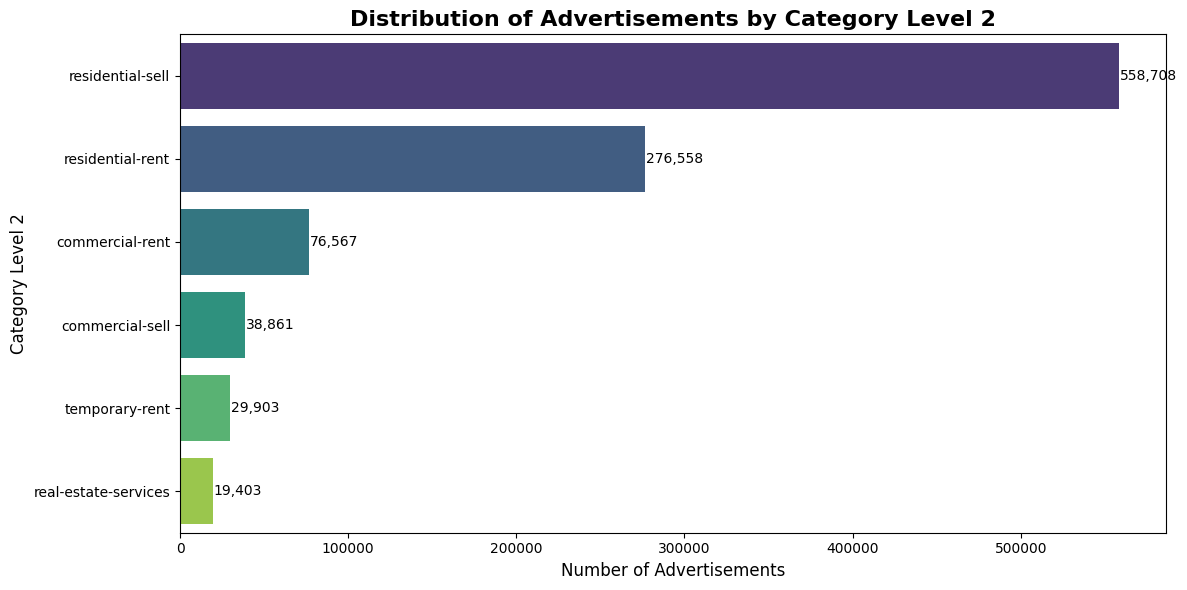


Category Level 3 Visualizations


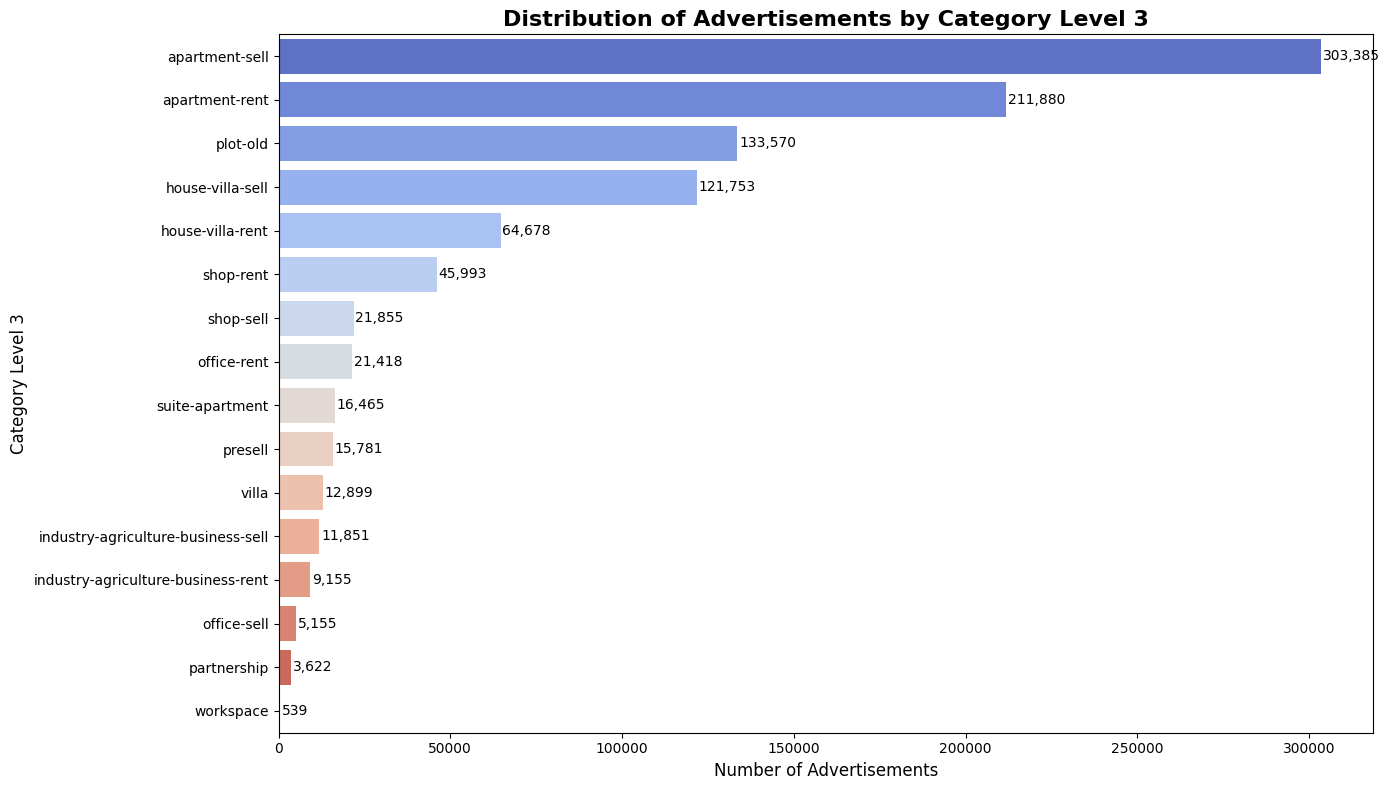

In [6]:
# EDA Quesation 1
# Check for cat2_slug
if 'cat2_slug' in df.columns:
    print(" 'cat2_slug' (Category Level 2) column exists")
    print(f"   Number of categories: {df['cat2_slug'].nunique()}")
    print(f"   Categories: {df['cat2_slug'].unique().tolist()}")
else:
    print(" 'cat2_slug' column does not exist!")

# Check for cat3_slug
if 'cat3_slug' in df.columns:
    print("\n 'cat3_slug' (Category Level 3) column exists")
    print(f"   Number of categories: {df['cat3_slug'].nunique()}")
    print(f"   First 10 categories: {df['cat3_slug'].unique()[:10].tolist()}")
else:
    print(" 'cat3_slug' column does not exist!")


# Calculate counts and percentages
cat2_counts = df['cat2_slug'].value_counts()

# Category Level 2 Visualizations

print("\n" + "="*60)
print("Category Level 2 Visualizations")
print("="*60)

# Horizontal bar chart for Level 2
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='cat2_slug', order=cat2_counts.index, palette='viridis')
plt.title('Distribution of Advertisements by Category Level 2', fontsize=16, fontweight='bold')
plt.xlabel('Number of Advertisements', fontsize=12)
plt.ylabel('Category Level 2', fontsize=12)

# Add count labels on bars
for i, v in enumerate(cat2_counts.values):
    plt.text(v + 500, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


# Calculate counts and percentages
cat3_counts = df['cat3_slug'].value_counts()

# Category Level 3 Visualizations

print("\n" + "="*60)
print("Category Level 3 Visualizations")
print("="*60)

# Horizontal bar chart for top 20 Level 3 categories
plt.figure(figsize=(14, 8))
bars = sns.barplot(x=cat3_counts.values, y=cat3_counts.index, palette='coolwarm')
plt.title('Distribution of Advertisements by Category Level 3',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Advertisements', fontsize=12)
plt.ylabel('Category Level 3', fontsize=12)

# Add count labels on bars
for i, v in enumerate(cat3_counts.values):
    plt.text(v + 500, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
